# NLP: FinBERT Full Fine-Tuning — Exp 2: Label Smoothing

This notebook extends the baseline full fine-tuning of `ProsusAI/finbert` by introducing a regularization technique designed to address the class imbalance and overconfidence observed in the first experiment.

**Changes from Exp 1:**
- **Label smoothing (ε = 0.05):** Prevents the model from assigning probability 1.0 to the correct class, improving calibration (lower ECE) and generalization.

**Key Steps:**
1. **Data Prep & Splitting:** Same stratified split as Exp 1 — Train (80%), Validation (10%), Test (10%).
2. **Model Initialization:** Loading the base model with all parameters trainable (full fine-tuning).
3. **Training Loop:** Custom `LabelSmoothTrainer` subclassing HuggingFace `Trainer`, overriding `compute_loss` to inject label smoothing into `nn.CrossEntropyLoss`.
4. **Evaluation:** Accuracy, F1, ROC-AUC and ECE on the Test set — compared against Exp 1 baseline.
5. **Real-World API Test:** Benchmarking against live Alpha Vantage sentiment scores.
6. **Serialization:** Saving the best model checkpoint for deployment.

In [22]:
# Install required dependencies
%pip install transformers torch datasets pandas scikit-learn accelerate>=1.1.0

Note: you may need to restart the kernel to use updated packages.


## 1. Setup, Data Loading & Tokenization

*Note: This section follows the same cleaning and tokenization logic established in the Base Model Evaluation notebook.*

In [ ]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from collections import Counter
from datasets import Dataset
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
)

import warnings
from transformers import logging as hf_logging

os.environ["CUDA_VISIBLE_DEVICES"] = "0"
warnings.filterwarnings("ignore")
hf_logging.set_verbosity_error() 

# --- Configuration ---
SEED = 42
MODEL_NAME = "ProsusAI/finbert"
LABEL2ID = {"negative": 0, "neutral": 1, "positive": 2}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}

np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# --- Data Loading & Cleaning ---
DATA_PATH = os.path.abspath(os.path.join(os.getcwd(), "..", "data", "sentiment_dataset.csv"))
df = pd.read_csv(DATA_PATH)

df = df[["text", "sentiment"]].copy()
df["text"] = df["text"].astype(str).str.strip()
df["sentiment"] = df["sentiment"].astype(str).str.strip().str.lower()
df = df.dropna(subset=["text", "sentiment"])
df = df[df["text"] != ""]
df = df[df["sentiment"].isin(LABEL2ID.keys())]
df = df.drop_duplicates(subset=["text", "sentiment"]).reset_index(drop=True)
df["label"] = df["sentiment"].map(LABEL2ID).astype(int)

# --- Stratified Split: Train (80%), Validation (10%), Test (10%) ---
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=SEED, stratify=df["label"])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=SEED, stratify=temp_df["label"])

print(f"Shapes: train -> {train_df.shape}, val -> {val_df.shape}, test -> {test_df.shape}")

# --- Tokenization ---
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_batch(batch):
    return tokenizer(batch["text"], truncation=True, max_length=128)

train_tok = Dataset.from_pandas(train_df[["text", "label"]].reset_index(drop=True)).map(tokenize_batch, batched=True)
val_tok = Dataset.from_pandas(val_df[["text", "label"]].reset_index(drop=True)).map(tokenize_batch, batched=True)
test_tok = Dataset.from_pandas(test_df[["text", "label"]].reset_index(drop=True)).map(tokenize_batch, batched=True)

cols = ["input_ids", "attention_mask", "label"]
if "token_type_ids" in train_tok.column_names:
    cols.append("token_type_ids")

train_tok.set_format(type="torch", columns=cols)
val_tok.set_format(type="torch", columns=cols)
test_tok.set_format(type="torch", columns=cols)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

Shapes: train -> (13004, 3), val -> (1625, 3), test -> (1626, 3)


Map:   0%|          | 0/13004 [00:00<?, ? examples/s]

Map:   0%|          | 0/1625 [00:00<?, ? examples/s]

Map:   0%|          | 0/1626 [00:00<?, ? examples/s]

## 2. Model Initialization

We load the base FinBERT model. By default, `AutoModelForSequenceClassification` leaves all ~109 million parameters trainable, which is exactly what we want for a full fine-tuning approach.

In [24]:
# Initialize the model with our specific label mappings
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
)

print(f"Model number of labels: {model.config.num_labels}")
print(f"id2label mapping: {model.config.id2label}")

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters:      {total_params:,}")
print(f"Trainable parameters:  {trainable_params:,}  ({100 * trainable_params / total_params:.2f}%)")

# Define the metrics we want to track during training
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="weighted", zero_division=0
    )
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model number of labels: 3
id2label mapping: {0: 'negative', 1: 'neutral', 2: 'positive'}

Total parameters:      109,484,547
Trainable parameters:  109,484,547  (100.00%)


## 3. Training with Hugging Face Trainer

We extend the standard `Trainer` API with a custom subclass — `LabelSmoothTrainer` — that overrides `compute_loss` to apply a new technique:

- **Label smoothing (`ε = 0.05`):** Redistributes a small fraction of the target probability mass across all classes. This softens the training signal, reduces overconfidence on ambiguous examples.

In [25]:
# TRAINER WITH LABEL SMOOTHING 
class LabelSmoothingTrainer(Trainer):
    def __init__(self, *args, label_smoothing: float = 0.0, **kwargs):
        super().__init__(*args, **kwargs)
        self.label_smoothing = label_smoothing

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop("labels")
        outputs = model(**inputs)
        loss_fn = nn.CrossEntropyLoss(label_smoothing=self.label_smoothing)
        loss    = loss_fn(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

In [ ]:
# TRAINING ARGUMENTS
collator = DataCollatorWithPadding(tokenizer=tokenizer)

training_args = TrainingArguments(
    output_dir            = SAVE_DIR,
    eval_strategy         = "epoch",
    save_strategy         = "epoch",
    logging_strategy      = "steps",
    logging_steps         = 50,
    learning_rate         = 2e-5,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size  = 32,
    num_train_epochs      = 3,
    weight_decay          = 0.01,
    load_best_model_at_end= True,
    metric_for_best_model = "f1",
    greater_is_better     = True,
    save_total_limit      = 1,
    report_to             = "none",
    seed                  = SEED,
)

trainer = LabelSmoothingTrainer(
    model          = model,
    args           = training_args,
    train_dataset  = train_tok,
    eval_dataset   = val_tok,
    data_collator  = collator,
    compute_metrics= compute_metrics,
    label_smoothing= 0.05,
)

print("Starting full fine-tuning with label smoothing...")
trainer.train()

Starting full fine-tuning with class weights + label smoothing...
{'loss': '0.9975', 'grad_norm': '4.58', 'learning_rate': '1.92e-05', 'epoch': '0.1229'}
{'loss': '0.7233', 'grad_norm': '3.836', 'learning_rate': '1.838e-05', 'epoch': '0.2457'}
{'loss': '0.6595', 'grad_norm': '5.253', 'learning_rate': '1.756e-05', 'epoch': '0.3686'}
{'loss': '0.5798', 'grad_norm': '3.564', 'learning_rate': '1.674e-05', 'epoch': '0.4914'}
{'loss': '0.5194', 'grad_norm': '4.919', 'learning_rate': '1.592e-05', 'epoch': '0.6143'}
{'loss': '0.5179', 'grad_norm': '5.206', 'learning_rate': '1.51e-05', 'epoch': '0.7371'}
{'loss': '0.5074', 'grad_norm': '4.719', 'learning_rate': '1.428e-05', 'epoch': '0.86'}
{'loss': '0.5324', 'grad_norm': '8.892', 'learning_rate': '1.346e-05', 'epoch': '0.9828'}
{'eval_loss': '0.4853', 'eval_accuracy': '0.8486', 'eval_precision': '0.8473', 'eval_recall': '0.8486', 'eval_f1': '0.8475', 'eval_runtime': '4.158', 'eval_samples_per_second': '390.8', 'eval_steps_per_second': '6.252',

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.4128', 'grad_norm': '5.428', 'learning_rate': '1.265e-05', 'epoch': '1.106'}
{'loss': '0.3987', 'grad_norm': '4.867', 'learning_rate': '1.183e-05', 'epoch': '1.229'}
{'loss': '0.4009', 'grad_norm': '5.108', 'learning_rate': '1.101e-05', 'epoch': '1.351'}
{'loss': '0.419', 'grad_norm': '5.832', 'learning_rate': '1.019e-05', 'epoch': '1.474'}
{'loss': '0.3995', 'grad_norm': '5.391', 'learning_rate': '9.369e-06', 'epoch': '1.597'}
{'loss': '0.3984', 'grad_norm': '6.778', 'learning_rate': '8.55e-06', 'epoch': '1.72'}
{'loss': '0.4003', 'grad_norm': '4.886', 'learning_rate': '7.731e-06', 'epoch': '1.843'}
{'loss': '0.4055', 'grad_norm': '8.607', 'learning_rate': '6.912e-06', 'epoch': '1.966'}
{'eval_loss': '0.4835', 'eval_accuracy': '0.848', 'eval_precision': '0.8562', 'eval_recall': '0.848', 'eval_f1': '0.8503', 'eval_runtime': '4.181', 'eval_samples_per_second': '388.7', 'eval_steps_per_second': '6.219', 'epoch': '2'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.3257', 'grad_norm': '4.463', 'learning_rate': '6.093e-06', 'epoch': '2.088'}
{'loss': '0.3089', 'grad_norm': '6.703', 'learning_rate': '5.274e-06', 'epoch': '2.211'}
{'loss': '0.3136', 'grad_norm': '5.677', 'learning_rate': '4.455e-06', 'epoch': '2.334'}
{'loss': '0.2985', 'grad_norm': '3.282', 'learning_rate': '3.636e-06', 'epoch': '2.457'}
{'loss': '0.3206', 'grad_norm': '2.967', 'learning_rate': '2.817e-06', 'epoch': '2.58'}
{'loss': '0.3299', 'grad_norm': '2.712', 'learning_rate': '1.998e-06', 'epoch': '2.703'}
{'loss': '0.3', 'grad_norm': '2.508', 'learning_rate': '1.179e-06', 'epoch': '2.826'}
{'loss': '0.3216', 'grad_norm': '7.082', 'learning_rate': '3.604e-07', 'epoch': '2.948'}
{'eval_loss': '0.4874', 'eval_accuracy': '0.8615', 'eval_precision': '0.8643', 'eval_recall': '0.8615', 'eval_f1': '0.8625', 'eval_runtime': '4.162', 'eval_samples_per_second': '390.4', 'eval_steps_per_second': '6.246', 'epoch': '3'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '347', 'train_samples_per_second': '112.4', 'train_steps_per_second': '3.519', 'train_loss': '0.4472', 'epoch': '3'}


TrainOutput(global_step=1221, training_loss=0.4471854757422995, metrics={'train_runtime': 346.9585, 'train_samples_per_second': 112.44, 'train_steps_per_second': 3.519, 'train_loss': 0.4471854757422995, 'epoch': 3.0})

## 4. Evaluation on Test Set

Once training is complete, we evaluate the best model on our completely unseen Test set to gauge its true generalization capabilities.

{'val_loss': '0.4874', 'val_accuracy': '0.8615', 'val_precision': '0.8643', 'val_recall': '0.8615', 'val_f1': '0.8625', 'val_runtime': '4.144', 'val_samples_per_second': '392.1', 'val_steps_per_second': '6.273', 'epoch': '3'}
{'test_loss': '0.5186', 'test_accuracy': '0.8487', 'test_precision': '0.8511', 'test_recall': '0.8487', 'test_f1': '0.8497', 'test_runtime': '4.032', 'test_samples_per_second': '403.3', 'test_steps_per_second': '6.449', 'epoch': '3'}
Validation metrics:
{'val_loss': 0.48743194341659546, 'val_accuracy': 0.8615384615384616, 'val_precision': 0.8643342552897769, 'val_recall': 0.8615384615384616, 'val_f1': 0.862496028716917, 'val_runtime': 4.1445, 'val_samples_per_second': 392.089, 'val_steps_per_second': 6.273, 'epoch': 3.0}

Test metrics:
{'test_loss': 0.5186399817466736, 'test_accuracy': 0.8487084870848709, 'test_precision': 0.8511142911455836, 'test_recall': 0.8487084870848709, 'test_f1': 0.84971598031617, 'test_runtime': 4.0317, 'test_samples_per_second': 403.307,

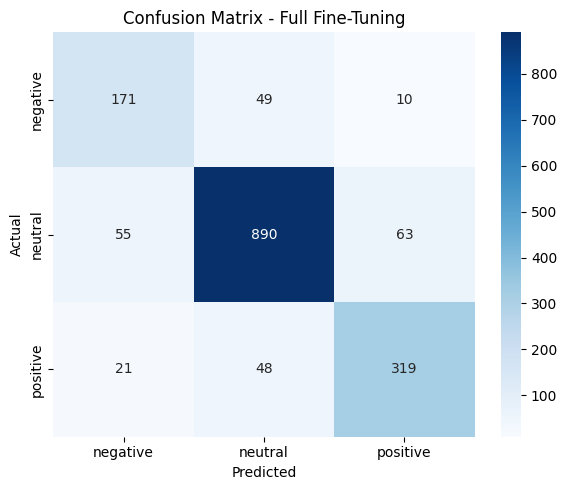

ROC-AUC (weighted OvR): 0.9443


In [28]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import label_binarize

# 1. Standard Hugging Face Evaluation
val_metrics = trainer.evaluate(eval_dataset=val_tok, metric_key_prefix="val")
test_metrics = trainer.evaluate(eval_dataset=test_tok, metric_key_prefix="test")

print("Validation metrics:")
print(val_metrics)
print("\nTest metrics:")
print(test_metrics)

# 2. Detailed Predictions on Test Set
predictions = trainer.predict(test_tok)
preds = predictions.predictions.argmax(axis=-1)
labels = predictions.label_ids
probs = torch.softmax(torch.tensor(predictions.predictions), dim=-1).numpy()

# 3. Classification Report
print("=" * 60)
print("CLASSIFICATION REPORT - Full Fine-Tuning")
print("=" * 60)
print(classification_report(labels, preds, target_names=['negative', 'neutral', 'positive']))

# 4. Confusion Matrix
cm = confusion_matrix(labels, preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['negative', 'neutral', 'positive'],
            yticklabels=['negative', 'neutral', 'positive'])
plt.title('Confusion Matrix - Full Fine-Tuning')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix_full.png', dpi=150)
plt.show()

# 5. ROC-AUC Score
labels_bin = label_binarize(labels, classes=[0, 1, 2])
auc = roc_auc_score(labels_bin, probs, multi_class='ovr', average='weighted')
print(f"ROC-AUC (weighted OvR): {auc:.4f}")

## 5. Live API Benchmarking

We fetch the latest financial news via the Alpha Vantage API and run it through our newly fine-tuned model. We style the Pandas DataFrame to visually highlight agreements (green) and disagreements (red) between the API's native score and our model's prediction.

In [32]:
from datetime import date
import requests
from scipy.stats import pearsonr

TEMPERATURE = 2.5

# Reusable inference function for new text
def predict_texts(texts, model, tokenizer, temperature=2.5, max_length=128):
    if isinstance(texts, str): texts = [texts]
    device = model.device
    enc = tokenizer(texts, return_tensors="pt", truncation=True, padding=True, max_length=max_length)
    enc = {k: v.to(device) for k, v in enc.items()}

    model.eval()
    with torch.no_grad():
        logits = model(**enc).logits
        probs  = torch.softmax(logits / temperature, dim=-1) 
    return probs.cpu().numpy()

In [ ]:
# Define Universe and API params
expanded_universe = {
    "Equities_US_Broad": ["SPY", "QQQ", "DIA", "IWM"],
    "Equities_Global":   ["EFA", "EEM", "URTH"],
    "Sectors_US":        ["XLF", "XLV", "XLE", "XLK"],
    "Commodities":       ["GLD", "SLV", "USO", "DBA"],
    "Fixed_Income":      ["TLT", "AGG"],
    "Cryptocurrency":    ["BTC-USD", "ETH-USD", "BNB-USD"]
}

TICKERS = [t for group in expanded_universe.values() for t in group]
ALPHAVANTAGE_KEY = "your_api_key_here"  # Replace with your actual Alpha Vantage API key
END_DATE   = date.today().isoformat()
START_DATE = (date.today() - pd.Timedelta(weeks=1)).isoformat()
LABELS     = ["negative", "neutral", "positive"]

def normalize_label(label):
    label = label.lower()
    if "positive" in label or "bullish" in label: return "positive"
    if "negative" in label or "bearish" in label: return "negative"
    return "neutral"

# Fetch Data
rows = []
print("Fetching live news from Alpha Vantage...")
for ticker in TICKERS:
    params = {
        "function": "NEWS_SENTIMENT", "tickers": ticker,
        "time_from": START_DATE.replace("-","") + "T0000",
        "time_to":   END_DATE.replace("-","")   + "T2359",
        "limit": 200, "apikey": ALPHAVANTAGE_KEY,
    }
    try:
        # Request data from API
        feed = requests.get("https://www.alphavantage.co/query", params=params, timeout=15).json().get("feed", [])
        for a in feed:
            rows.append({
                "ticker":    ticker,
                "date":      a.get("time_published", "")[:10],
                "title":     a.get("title", ""),
                "text":      f"{a.get('title','')}. {a.get('summary','')}".strip(),
                "url":       a.get("url", ""),
                "av_label":  normalize_label(a.get("overall_sentiment_label", "Neutral")),
                "av_score":  float(a.get("overall_sentiment_score", 0.0) or 0.0),
            })
    except Exception as e:
        print(f"Error {ticker}: {e}")

df_api = pd.DataFrame(rows).drop_duplicates(subset=["text"]).reset_index(drop=True)

In [35]:
# Generate Predictions
api_probs = predict_texts(df_api["text"].tolist(), model, tokenizer, temperature=2.5)
df_api["finbert_score"] = np.array([-1, 0, 1]) @ api_probs.T
df_api["finbert_label"] = [LABELS[p.argmax()] for p in api_probs]

# Display Styled Comparison
pd.set_option("display.max_colwidth", None)

def color_label(val, av_series):
    colors = []
    for i, v in enumerate(val):
        match = v == av_series.iloc[i]
        c = "color: #155724; font-weight: bold" if match else "color: #721c24; font-weight: bold"
        colors.append(c)
    return colors

display(
    df_api[["ticker", "date", "text", "av_label", "av_score", "finbert_label", "finbert_score"]]
    .head(15)
    .style
    .apply(lambda s: color_label(s, df_api["av_label"]), subset=["finbert_label"])
    .format({"av_score": "{:.3f}", "finbert_score": "{:.3f}"})
    .set_caption("finbert_label in green if it matches av_label, red if it disagrees")
)

# Metrics
agreement = (df_api["av_label"] == df_api["finbert_label"]).mean() * 100
r, p = pearsonr(df_api["av_score"], df_api["finbert_score"])
print(f"\nLabel Agreement:     {agreement:.1f}%")
print(f"Pearson Correlation: {r:.4f}  (p={p:.4f})")

,ticker,date,text,av_label,av_score,finbert_label,finbert_score
0,SPY,20260517T0,"SPDR S&P 500 ETF Trust Trade Ideas — VANTAGE:SPY. This article compiles several trade ideas and analyses for the SPDR S&P 500 ETF Trust (SPY) from various contributors. It covers market-moving headlines, technical analysis across multiple timeframes, GEX (Gamma Exposure) insights, and potential bullish and bearish scenarios for the upcoming week. The analyses frequently reference economic data, corporate earnings, and geopolitical factors impacting the S&P 500.",positive,0.164,neutral,0.012
1,SPY,20260517T0,"SPDR S&P 500 ETF Trust Trade Ideas — VANTAGE:SPY. This article compiles several trade ideas and analyses for the SPDR S&P 500 ETF Trust (SPY) from various contributors on TradingView. It covers diverse perspectives ranging from bullish continuation scenarios and long option strategies to warnings of potential double tops, market exhaustion, and even a bearish geopolitical outlook. Key technical levels, economic data, and sentiment indicators are frequently discussed by the contributing analysts.",positive,0.260,neutral,0.007
2,SPY,20260516T1,"State Street SPDR S&P 500 ETF Trust Trade Ideas — EIGHTCAP:SPY. This article compiles several trade ideas and analyses for the State Street SPDR S&P 500 ETF Trust (SPY) from various contributors. It covers short-term bullish and bearish scenarios, range trading strategies, support and resistance levels, and broader market themes and economic data influencing SPY. The analyses emphasize identifying market structure, order flow, and managing risk based on technical indicators and price action.",neutral,-0.049,neutral,0.020
3,SPY,20260516T1,"SPDR S&P 500 ETF Trust Sees Inflows Amid Tech Strength. The SPDR S&P 500 ETF Trust ($SPY) has seen a 5-day net inflow of $3.59 billion despite a slight weekly dip, driven by strong market sentiment towards its major tech holdings. Nvidia, Apple, and Microsoft are key contributors to this trend, fueled by AI advancements, robust earnings, and strategic corporate decisions. This indicates continued investor confidence in the technology sector's growth potential within the S&P 500.",positive,0.517,positive,0.564
4,SPY,20260516T0,"SPDR S&P 500 ETF Trust (SPY) Daily Update, 5/15/2026. The SPDR S&P 500 ETF Trust (SPY) declined 1.2% on May 15, impacted by a tech stock pullback, rising oil prices and Treasury yields, and disappointment from the U.S.-China summit. Despite daily losses, SPY experienced $5 billion in net inflows over the past five days. The ETF has a ""Strong Buy"" rating with an implied upside potential of 15.55%, yet hedge fund managers decreased their holdings in the last quarter.",neutral,0.025,negative,-0.485
5,SPY,20260515T1,"Stock Market Live May 15, 2026: S&P 500 (SPY) Deep in the Red. The S&P 500, Dow Jones, and Nasdaq are all trading significantly lower on May 15, 2026, with the S&P 500 and its ETF, SPY, deep in the red. This market pullback is attributed to the lack of major deals from the Trump-Xi meeting and a potential breakdown in the ""unsustainable"" rally of tech stocks. Dell (DELL) is a focus, with analysts expecting strong earnings driven by AI demand, while Cisco (CSCO) posted better-than-expected third-quarter results and increased its AI infrastructure orders guidance.",neutral,0.118,negative,-0.545
6,SPY,20260515T0,SPY ETF Falls 1.2%. The SPY ETF experienced a 1.2% drop. This brief report highlights the recent performance of the popular S&P 500 tracking ETF.,negative,-0.639,negative,-0.506
7,SPY,20260514T2,"Stock Market Today: SPY, QQQ Accelerate to All-Time Highs on ‘Extremely Positive’ Trump-Xi Meeting. U.S. equities, including the S&P 500 ETF (SPY) and Nasdaq 100 ETF (QQQ), reached all-time highs following a ""extremely positive"" meeting between President Trump and Chinese President Xi Jinping. The discussions focused on economic ties, U.S. business access to China, and the war in Iran. Tech stocks, particularly Nvidia (NVDA) and Broadc


Label Agreement:     52.9%
Pearson Correlation: 0.5707  (p=0.0167)


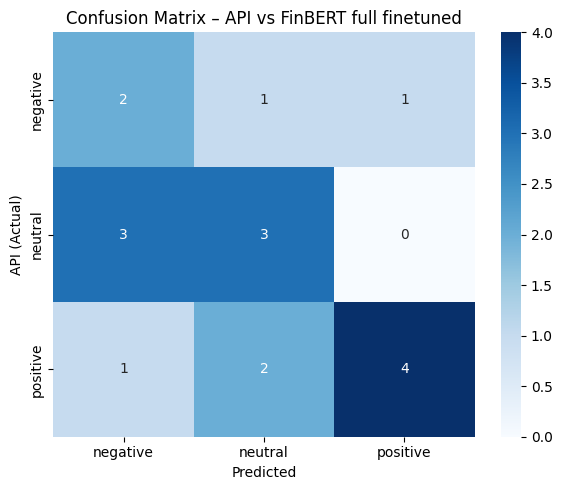

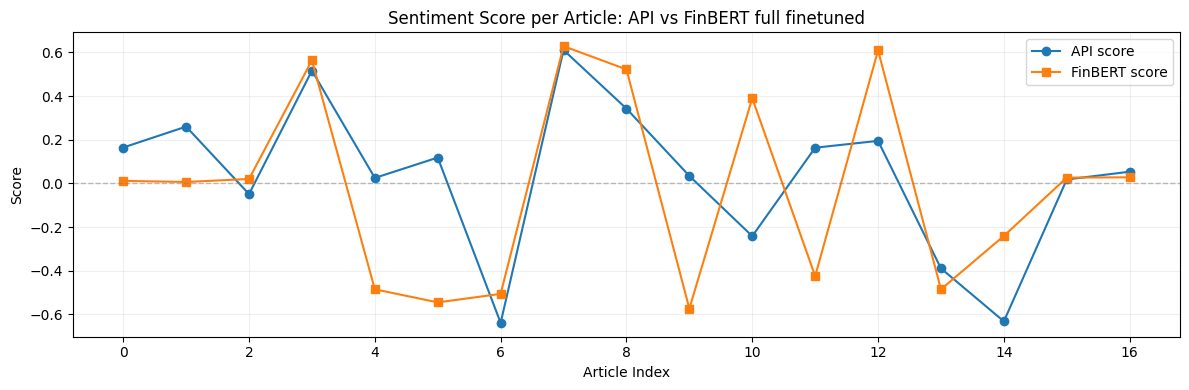

In [36]:
cm_api = confusion_matrix(df_api["av_label"], df_api["finbert_label"], labels=LABELS)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_api, annot=True, fmt="d", cmap="Blues",
            xticklabels=LABELS, yticklabels=LABELS)
plt.title("Confusion Matrix – API vs FinBERT full finetuned")
plt.ylabel("API (Actual)"); plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("confusion_matrix_av_vs_finbert_full_finetuned.png", dpi=150)
plt.show()


# Plot Score Comparison
plt.figure(figsize=(12, 4))
plt.plot(df_api.index, df_api["av_score"],      marker="o", linewidth=1.5, label="API score")
plt.plot(df_api.index, df_api["finbert_score"], marker="s", linewidth=1.5, label="FinBERT score")
plt.axhline(0, linestyle="--", linewidth=1, color="gray", alpha=0.5)
plt.title("Sentiment Score per Article: API vs FinBERT full finetuned")
plt.xlabel("Article Index"); plt.ylabel("Score")
plt.legend(); plt.grid(alpha=0.2); plt.tight_layout()
plt.savefig("score_comparison.png", dpi=150)
plt.show()

## 6. Advanced Metrics & Model Serialization

We check the calibration and perplexity, calculate the disk size of the model, and save the final fine-tuned weights and tokenizer to our local `models` directory.

In [31]:
import math

# 1. Expected Calibration Error
def compute_ece(probs, labels, n_bins=10):
    confidences = probs.max(axis=-1)
    correct = (probs.argmax(axis=-1) == labels).astype(float)
    bins = np.linspace(0, 1, n_bins + 1)
    ece = sum(
        abs(correct[mask].mean() - confidences[mask].mean()) * mask.sum()
        for i in range(n_bins)
        if (mask := (confidences > bins[i]) & (confidences <= bins[i+1])).sum() > 0
    )
    return ece / len(labels)

print(f"ECE (Calibration): {compute_ece(probs, labels):.4f} (0 = perfect)")

# 2. Pseudo-Perplexity
test_loss = predictions.metrics.get('test_loss', None)
if test_loss:
    ppl_approx = math.exp(test_loss)
    print(f"Pseudo-Perplexity (approx. via test loss): {ppl_approx:.4f}")

# 3. Save Model & Tokenizer
SAVE_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", "models", "finbert_full_finetuned"))
trainer.save_model(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)
print(f"\nModel and tokenizer successfully saved to: {SAVE_DIR}")

# 4. Calculate Disk Size
model_size = sum(
    os.path.getsize(os.path.join(SAVE_DIR, f))
    for f in os.listdir(SAVE_DIR) if os.path.isfile(os.path.join(SAVE_DIR, f))
) / (1024 ** 2)
print(f"Model size on disk: {model_size:.3f} MB")

ECE (Calibration): 0.0568 (0 = perfect)
Pseudo-Perplexity (approx. via test loss): 1.6797


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Model and tokenizer successfully saved to: /kaggle/models/finbert_full_finetuned
Model size on disk: 418.358 MB
